## Week 9 Lab exercises

In this week we will investigate numerical interpolation and integration.

In [14]:
%pip install sympy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 14.6 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 6.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [sympy]32m1/2 [sympy]
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
from sympy import symbols, simplify, pprint
from scipy.interpolate import lagrange
from scipy.integrate import trapezoid
from scipy.integrate import simpson
from scipy.interpolate import CubicHermiteSpline
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# We will be working with this test function throughout the exercises:

def get_y_test_function(a_x_points) :
    y_test = np.exp(-a_x_points*a_x_points) + np.sin(a_x_points)
    return y_test

def get_dydx_test_function(a_x_points) :
    dydt_test = -2.0 * a_x_points * np.exp(-a_x_points*a_x_points) + np.cos(a_x_points)
    return dydt_test   

### ACTIVITY 1 - interpolation: 

We are given two points and are asked to fit a function to them. We construct a Lagrange interpolating polynomial using sympy to work out the polynomial for us. We obtain a first order polynomial that goes through the points and plot it.

Python has a function for calculating Lagrange polynomials for a given set of points called `scipy.interpolate.lagrange`. We use this to check our polynomial.


Using sympy we get 0.12544570880996*x + 0.787209250119254
Using the scipy function we get 
  
0.1254 x + 0.7872
We can also return the coefficients of the polynomial as an array:  [0.12544571 0.78720925]


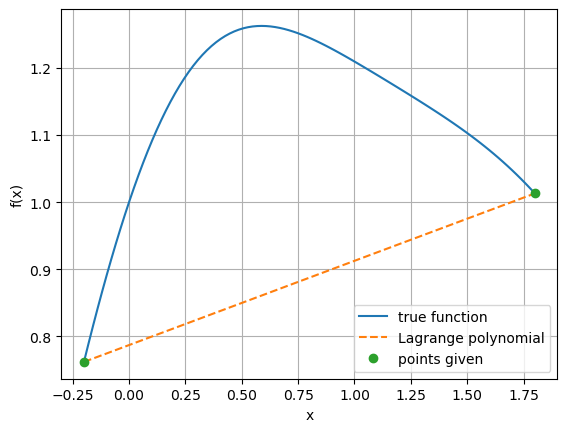

In [3]:
x_points = np.array([-0.2, 1.8])
y_points = get_y_test_function(x_points)

# Construct the polynomial using sympy
[x1,x2] = x_points
[f1,f2] = y_points

x = symbols('x') # Makes x algebraic 
L1 = (x - x2 ) / (x1 - x2)
L2 = (x - x1 ) / (x2 - x1)
P = f1 * L1 + f2 * L2
print("Using sympy we get", simplify(P))

lagrange_polynomial = lagrange(x_points, y_points)
print("Using the scipy function we get \n",lagrange_polynomial)
print("We can also return the coefficients of the polynomial as an array: ", 
      lagrange_polynomial.coef)

x_true = np.linspace(-0.2,1.8,100)
plt.plot(x_true, get_y_test_function(x_true), '-', label="true function")
plt.plot(x_true, lagrange_polynomial(x_true), '--', label="Lagrange polynomial")
plt.plot(x_points, y_points, 'o', label="points given")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid();

### Q1.1 Higher order Lagrange polynomial

Now we are given 3 points! What order polynomial can we construct? Construct the Langrange interpolating polynomial from scratch, verify it using the `scipy.interpolate.lagrange` function and then plot it as we did above.

Using sympy we get -0.581641511672685*x**2 + 1.25612865593004*x + 0.636498443122615
Using the scipy function we get 
          2
-0.3711 x + 0.7191 x + 0.9208
We can also return the coefficients of the polynomial as an array:  [-0.37105569  0.71913482  0.9207893 ]


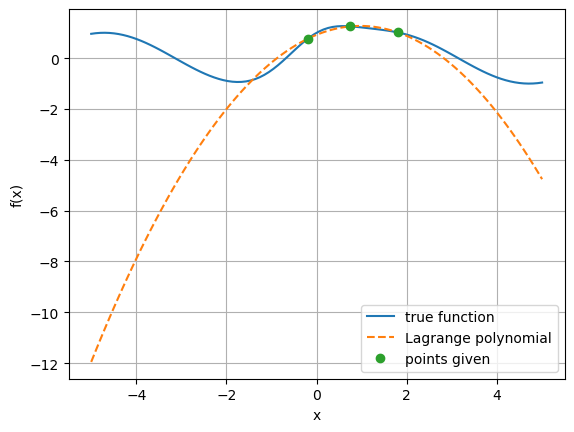

In [17]:
x_points = np.array([-0.2, 0.75, 1.8])
y_points = get_y_test_function(x_points)

[x1,x2,x3] = x_points
[f1,f2,f3] = y_points

x = symbols('x')
L1 = ((x-x3)*(x-x2))/((x1-x3)*(x1-x3))
L2 = ((x-x3)*(x-x1))/((x2-x3)*(x2-x1))
L3 = ((x-x2)*(x-x1))/((x3-x2)*(x3-x1))
P = f1*L1 + f2*L2 + f3*L3

print("Using sympy we get", simplify(P))

lagrange_polynomial = lagrange(x_points, y_points)
print("Using the scipy function we get \n", lagrange_polynomial)
print("We can also return the coefficients of the polynomial as an array: ",
      lagrange_polynomial.coef)

x_true = np.linspace(-5.0,5.0,100)
plt.plot(x_true, get_y_test_function(x_true), '-', label="true function")
plt.plot(x_true, lagrange_polynomial(x_true), '--', label="Lagrange polynomial")
plt.plot(x_points, y_points, 'o', label="points given")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid();

### Q1.2 Higher order Lagrange polynomial using many equal spaced points

To get a better fit over a wider range from $[-5.0,5.0]$ you decide to divide the interval into N points, and then fit a higher order polynomial using `scipy.interpolate.lagrange`. What happens as you increase N? Does the fit get better or worse? What is this phenomenon called?

Using the scipy function we get 
          4           3          2
0.01608 x - 0.05608 x - 0.3146 x + 0.7081 x + 0.9159
We can also return the coefficients of the polynomial as an array:  [ 0.01608319 -0.05608231 -0.31457181  0.70811636  0.91585186]


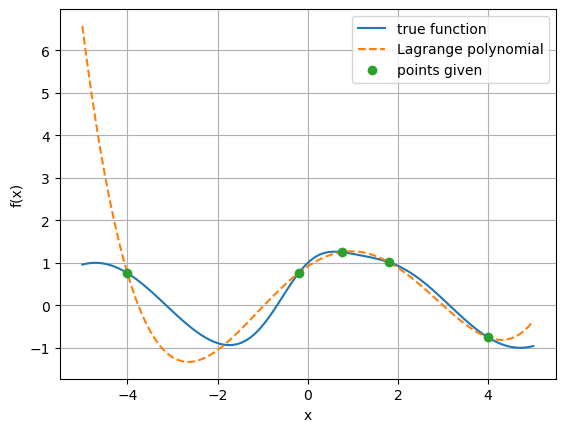

In [41]:
x_points = np.array([-4.0,-0.2, 0.75, 1.8,4])
y_points = get_y_test_function(x_points)

[x1,x2,x3,x4,x5] = x_points
[f1,f2,f3,f4,f5] = y_points




lagrange_polynomial = lagrange(x_points, y_points)
print("Using the scipy function we get \n", lagrange_polynomial)
print("We can also return the coefficients of the polynomial as an array: ",
      lagrange_polynomial.coef)

x_true = np.linspace(-5.0,5.0,100)
plt.plot(x_true, get_y_test_function(x_true), '-', label="true function")
plt.plot(x_true, lagrange_polynomial(x_true), '--', label="Lagrange polynomial")
plt.plot(x_points, y_points, 'o', label="points given")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid();

#As you increase N the the true function and polynomial start to become more of a curve as youre considefing more points on the curve. 
# Which in turn means a better fit

### Q1.3 Cubic Hermite spline

You decide to instead fit a composite Hermite polynomial to the points. What more information do you need? Construct the Hermite polynomial using the Python function `scipy.interpolate.CubicHermiteSpline`. What kind of object does this function return? How do you use it to plot the function you have constructed? What number of points do you need to get a good fit?

#### OPTIONAL: 

Construct a series of Lagrange polynomials that fit 3 points in the interval at a time, and compare the overall fit to the composite cubic Hermite polynomial fit. What is the problem with using Lagrange polynomials rather than Hermite ones when constructing a composite function?

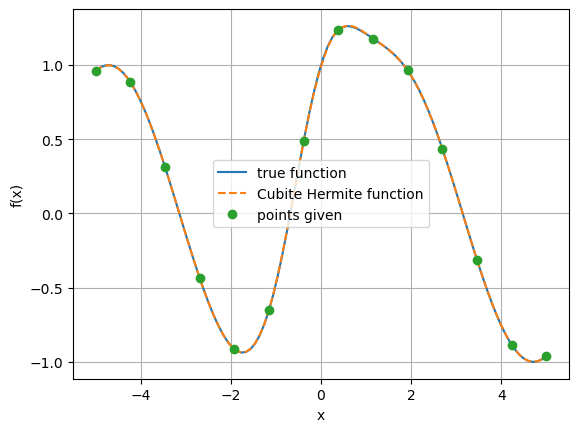

In [50]:
N = 14
a = -5
b = 5
x_points = np.linspace(a,b,N)
y_points = get_y_test_function(x_points)
dydx_points = get_dydx_test_function(x_points)

# Takes 3 points other than lagrange which takes 2.
cubichermitespline_polynomial = CubicHermiteSpline(x_points, y_points, dydx_points)

plt.plot(x_true, get_y_test_function(x_true), '-', label="true function")
plt.plot(x_true, cubichermitespline_polynomial(x_true), '--', label="Cubite Hermite function")
plt.plot(x_points, y_points, 'o', label="points given")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid();






In [8]:
# Optional using lagrange interpolation



### Q1.4 Gauss Lobato nodes

You finally decide to move the points so they are not evenly distributed, to the Gauss Lobato nodes. Find the location of the Gauss Lobato nodes for an integer N number of points and an interval $[-5,5]$ and fit a lagrange polynomial to it using `scipy.interpolate.lagrange`. What is the smallest number N that fits the points well (just comparing the differences by eye)?

In [9]:
# Your code here...



### ACTIVITY 2:
    
Below we have implemented the composite method for the trapezium rule applied to the function above for N points, and then checked it against the numpy function `scipy.integrate.trapezoid`.

In [10]:
# function to get integral using trapezoid rule
a = -5
b = 5
N = 10

# Implement your own version of the composite trapezoid rule
def get_test_integral(a_num_points) :
    x_integration = np.linspace(a , b,  a_num_points)
    y_integration = get_y_test_function(x_integration)
    dx = (b - a) / (a_num_points - 1)
    integral = (dx/2)*(y_integration[0] + 2 * sum(y_integration[1:a_num_points-1])
                       + y_integration[a_num_points-1])
    return integral

integral = get_test_integral(N)

# Check using the python function
x_integration = np.linspace(a , b,  N)
y_integration = get_y_test_function(x_integration)
integral_scipy = trapezoid(y_integration,x_integration)

print("The integral with ", N, " points is ", integral, integral_scipy)

NameError: name 'trapezoid' is not defined

### Q2.1 Trapezoid rule

Test the integral for a range of values of N and show that the error decreases at the expected order (what is this?).

In [11]:
# Your code here...



### Q2.2 Simpson's 3 point composite rule

Implement the composite method for the Simpson's 3 point rule with N points (from scratch, as was done above for the trapezoidal rule), then check it using the python function `scipy.integrate.simpson` and again show that the error decreases at the expected order.

In [12]:
# Your code here...

